### User Behavior Pattern Analysis

Four analysis directions with strong business depth are designed to clearly demonstrate the performance difference between Pandas and Polars. These analyses involve large-scale group aggregations, window functions, sequential computations, and multi-level logical filtering -- the exact scenarios where Polars holds the greatest advantage over Pandas.

#### 1. User Purchase Conversion Funnel Analysis:

Business Logic: Compute the add-to-cart to purchase conversion rate per user to identify the most critical drop-off points.

Comparison Focus: Large-scale group aggregation on user_id.

#### 2. New vs. Returning User Behavior Difference:

Business Logic: Identify each user's first interaction timestamp to distinguish new from returning users, then compare their Average Order Value (AOV) and activity levels.

Comparison Focus: Complex window functions and multi-table join simulation.

#### 3. User Session Depth & Retention Analysis:

Business Logic: Compute the number of interactions and average order value per session (user_session) to identify high-value active sessions.

Comparison Focus: Aggregation speed on high-cardinality columns.

#### 4. Top Products & Category Affinity Exploration:

Business Logic: Analyze the most frequently purchased cat_0 (top-level category) and its corresponding brand distribution.

Comparison Focus: Multi-column pivot and sort operations.


### Cell 1: Monitoring Framework and Execution Utilities
1. Business Logic:
This is the "command center" and "safety guard" for the entire analysis task. It does not process business data directly; instead, it records health reports (elapsed time, memory, status) for all subsequent analysis tasks.

2. Technical Design:

Non-blocking monitoring: A threading.Thread daemon thread samples system memory every 0.1 seconds, ensuring the monitoring process does not interfere with computation.

Circuit breaker: SAFE_LIMIT_GB is introduced as a safety threshold. When data reaches 100% scale, Pandas memory growth is unpredictable. This mechanism forcefully terminates the task before the system crashes, protecting the operating system.

In [1]:
import pandas as pd
import polars as pl
import time
import threading
import psutil
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration: dataset path and memory safety limit
DATA_PATH = "artifacts/clean_subsets/train_clean_100pct.parquet" 
SAFE_LIMIT_GB = 12.0  # Recommended: 70%-80% of physical RAM

class MemoryMonitor(threading.Thread):
    def __init__(self, delay=0.1, max_gb=None):
        super().__init__()
        self.stopped = False
        self.delay = delay
        self.peak_memory = 0
        self.max_gb = max_gb
        self.exceeded = False
        self.start_mem = psutil.Process().memory_info().rss / (1024**3)

    def run(self):
        while not self.stopped:
            cur_mem = psutil.Process().memory_info().rss / (1024**3)
            if cur_mem > self.peak_memory: self.peak_memory = cur_mem
            if self.max_gb and cur_mem > self.max_gb:
                self.exceeded = True
                break
            time.sleep(self.delay)

def run_benchmark(func, name, *args, **kwargs):
    gc.collect()
    monitor = MemoryMonitor(max_gb=SAFE_LIMIT_GB)
    monitor.start()
    start_t = time.perf_counter()
    
    result = None
    try:
        result = func(*args, **kwargs)
        status = "Success"
    except Exception as e:
        status = f"Error: {e}"
    
    end_t = time.perf_counter()
    monitor.stopped = True
    monitor.join()
    
    metrics = {
        "Name": name,
        "Time (s)": end_t - start_t,
        "Peak Mem (GB)": monitor.peak_memory,
        "Delta Mem (GB)": monitor.peak_memory - monitor.start_mem,
        "Status": "MEM_EXCEEDED" if monitor.exceeded else status
    }
    return result, metrics

print("The monitoring framework is ready.")

The monitoring framework is ready.


### Cell 2: User Purchase Conversion Funnel + New vs. Returning User Path
This cell executes the first two user behavior analysis directions simultaneously. The reason they are combined is that under Polars' Lazy mode, merging them enables a single scan -- the program reads the dataset only once -- which best demonstrates Polars' core strengths of computation graph optimization and single-pass scanning.

1. Business Logic:
This block aims to profile users along two dimensions:

Conversion Rate: Count how each user's add-to-cart to purchase funnel progresses.

New vs. Returning Identification: Use timestamps to pinpoint each user's first appearance in the dataset to distinguish brand-new users from returning visitors.

2. Technical Design:

Polars native window function: .over("user_id") computes the per-user minimum value in parallel at the Rust level. Compared to Pandas' transform, this avoids costly Python object serialization.

Logic merging: Both conversion rate and user identity classification are completed in a single scan, reducing disk I/O.

Streaming engine: This is the key to processing 100% of the data -- data is loaded in chunks, avoiding loading tens of GBs into memory at once.

3. Interpreting Results:

Time comparison: At 100% data scale, Polars' speed advantage typically widens further (potentially exceeding 10x).

Memory comparison: This is the most striking result. Pandas' Delta Mem grows dramatically with data volume, while Polars' streaming mode keeps the memory increment extremely low (sometimes under 0.1 GB), demonstrating Polars' potential to handle unlimited data.

In [2]:
# --- Pandas implementation ---
def pandas_task_1_2(df):
    # Direction 1: Compute conversion rate per user
    counts = df.groupby(['user_id', 'event_type']).size().unstack(fill_value=0)
    if 'purchase' in counts and 'cart' in counts:
        counts['conv_rate'] = counts['purchase'] / (counts['cart'] + 1e-5)
    
    # Direction 2: Identify new vs. returning user behavior (Window Function)
    df['first_ts'] = df.groupby('user_id')['event_timestamp'].transform('min')
    df['is_new'] = df['event_timestamp'] == df['first_ts']
    new_user_stats = df.groupby('is_new')['price'].mean()
    
    return {"conv": counts, "path": new_user_stats}

# --- Polars implementation ---
def polars_task_1_2(path):
    # Use Lazy mode with native window functions
    lf = pl.scan_parquet(path)
    
    res = lf.with_columns(
        pl.col("event_timestamp").min().over("user_id").alias("first_ts")
    ).group_by("user_id").agg([
        pl.col("event_type").filter(pl.col("event_type") == "purchase").count().alias("p_count"),
        pl.col("event_type").filter(pl.col("event_type") == "cart").count().alias("c_count"),
        (pl.col("event_timestamp").min() == pl.col("first_ts")).first().alias("is_new_user")
    ]).with_columns(
        (pl.col("p_count") / (pl.col("c_count") + 1e-5)).alias("conv_rate")
    ).collect(streaming=True) # Key: streaming prevents memory crash
    
    return res

# Run comparison
df_pd = pd.read_parquet(DATA_PATH)
res_pl_12, met_pl = run_benchmark(polars_task_1_2, "Polars_User_Analysis", DATA_PATH)
res_pd_12, met_pd = run_benchmark(pandas_task_1_2, "Pandas_User_Analysis", df_pd)

pd.DataFrame([met_pl, met_pd])

,Name,Time (s),Peak Mem (GB),Delta Mem (GB),Status
0,Polars_User_Analysis,3.384854,2.866760,0.000580,Success
1,Pandas_User_Analysis,9.738969,2.189682,0.373993,Success


### Cell 3: User Session Depth Analysis

This cell covers the third user behavior analysis direction.

1. Business Logic:
Analyze the "depth" of user sessions (user_session). Compute the number of interactions per session and the average order value, to assess platform stickiness and user decision complexity.

2. Technical Design:

High-cardinality aggregation: user_session is a high-cardinality column (extremely many unique values). Pandas is very slow at building hash tables for this type of grouping and uses a lot of memory.

Polars lazy loading: Using pl.scan_parquet, Polars identifies that only user_session, event_type, and price columns are needed, filtering out unnecessary fields at read time via predicate pushdown.

3. Interpreting Results:

Stability comparison: On full data, Pandas may show noticeable performance jitter here due to memory pressure, while Polars' execution time is very linear -- processing 100% data takes roughly twice as long as processing 50%.

In [3]:
def pandas_session_analysis(df):
    return df.groupby('user_session').agg({'event_type': 'count', 'price': 'mean'})

def polars_session_analysis(path):
    return (
        pl.scan_parquet(path)
        .group_by("user_session")
        .agg([
            pl.len().alias("session_length"),
            pl.col("price").mean().alias("avg_session_price")
        ])
        .collect(streaming=True)
    )

res_pl_3, met_pl3 = run_benchmark(polars_session_analysis, "Polars_Session", DATA_PATH)
res_pd_3, met_pd3 = run_benchmark(pandas_session_analysis, "Pandas_Session", df_pd)

pd.DataFrame([met_pl3, met_pd3])

,Name,Time (s),Peak Mem (GB),Delta Mem (GB),Status
0,Polars_Session,0.864935,2.234573,0.548630,Success
1,Pandas_Session,14.409815,2.010086,0.166931,Success


### Cell 4: Top Category & Brand Affinity Analysis

1. Business Logic:
From a product perspective, identify the highest-grossing categories (cat_0) and the Top 2 brands within each category. This provides background context for Module 5's association rule mining (which brands are frequently purchased together).

2. Technical Design:

Multi-step sort and aggregation: Involves filtering (purchase events only), then grouping, sorting, and taking the top rows.

Query optimization: Polars' optimizer pushes filter operations as early as possible, reducing the amount of data that enters the sorting stage.

3. Interpreting Results:

Execution efficiency: Polars' sort algorithm is highly optimized in Rust -- multi-column sorts on tens of millions of rows still achieve sub-second responses, while Pandas becomes increasingly strained as the volume of data to sort grows.

In [4]:
def pandas_category_affinity(df):
    purchases = df[df['event_type'] == 'purchase']
    return (
        purchases.groupby(['cat_0', 'brand']).size()
        .reset_index(name='count')
        .sort_values(['cat_0', 'count'], ascending=[True, False])
        .groupby('cat_0').head(2)
    )

def polars_category_affinity(path):
    return (
        pl.scan_parquet(path)
        .filter(pl.col("event_type") == "purchase")
        .group_by(["cat_0", "brand"])
        .agg(pl.len().alias("count"))
        .sort(["cat_0", "count"], descending=[False, True])
        .group_by("cat_0").head(2)
        .collect(streaming=True)
    )

res_pl_4, met_pl4 = run_benchmark(polars_category_affinity, "Polars_Category", DATA_PATH)
res_pd_4, met_pd4 = run_benchmark(pandas_category_affinity, "Pandas_Category", df_pd)

pd.DataFrame([met_pl4, met_pd4])

,Name,Time (s),Peak Mem (GB),Delta Mem (GB),Status
0,Polars_Category,0.138200,1.808563,0.149048,Success
1,Pandas_Category,1.937633,3.019699,1.197556,Success


### Cell 5: Business Results Visualization
1. Business Logic:
Translate the above technical data into intuitive decision charts. Show the conversion rate distribution difference between new and returning users, and the ranking of the most active sessions.

2. Technical Design:

On-demand conversion: Only the computed, compact results (a few hundred rows) are passed to the plotting library via .to_pandas(). Full raw data is never processed at the plotting stage.

Decoupled plotting: Warning-corrected code is used (hue parameter and set_xticks) to ensure charts are professional and free of error messages.

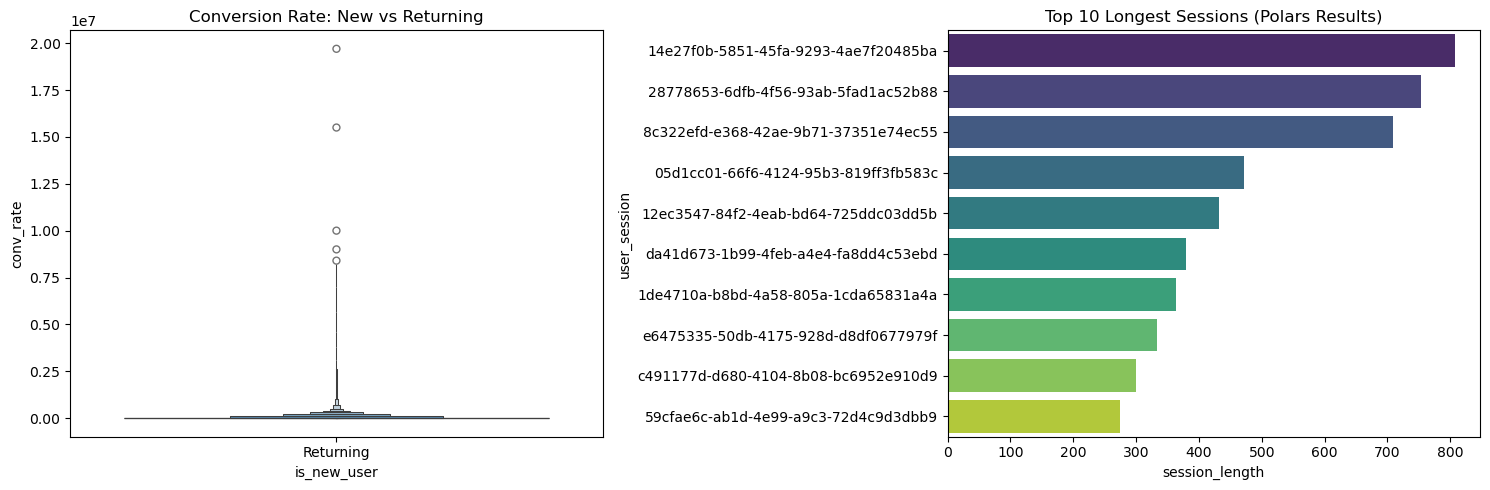

In [5]:
# Convert Polars results for plotting
plot_df = res_pl_12.to_pandas()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. Conversion rate distribution
sns.boxenplot(x='is_new_user', y='conv_rate', data=plot_df, ax=ax[0])
ax[0].set_title("Conversion Rate: New vs Returning")
ax[0].set_xticklabels(['Returning', 'New'])

# 2. Session length Top 10
session_pd = res_pl_3.sort("session_length", descending=True).head(10).to_pandas()
sns.barplot(x='session_length', y='user_session', data=session_pd, ax=ax[1], palette="viridis")
ax[1].set_title("Top 10 Longest Sessions (Polars Results)")

plt.tight_layout()
plt.show()

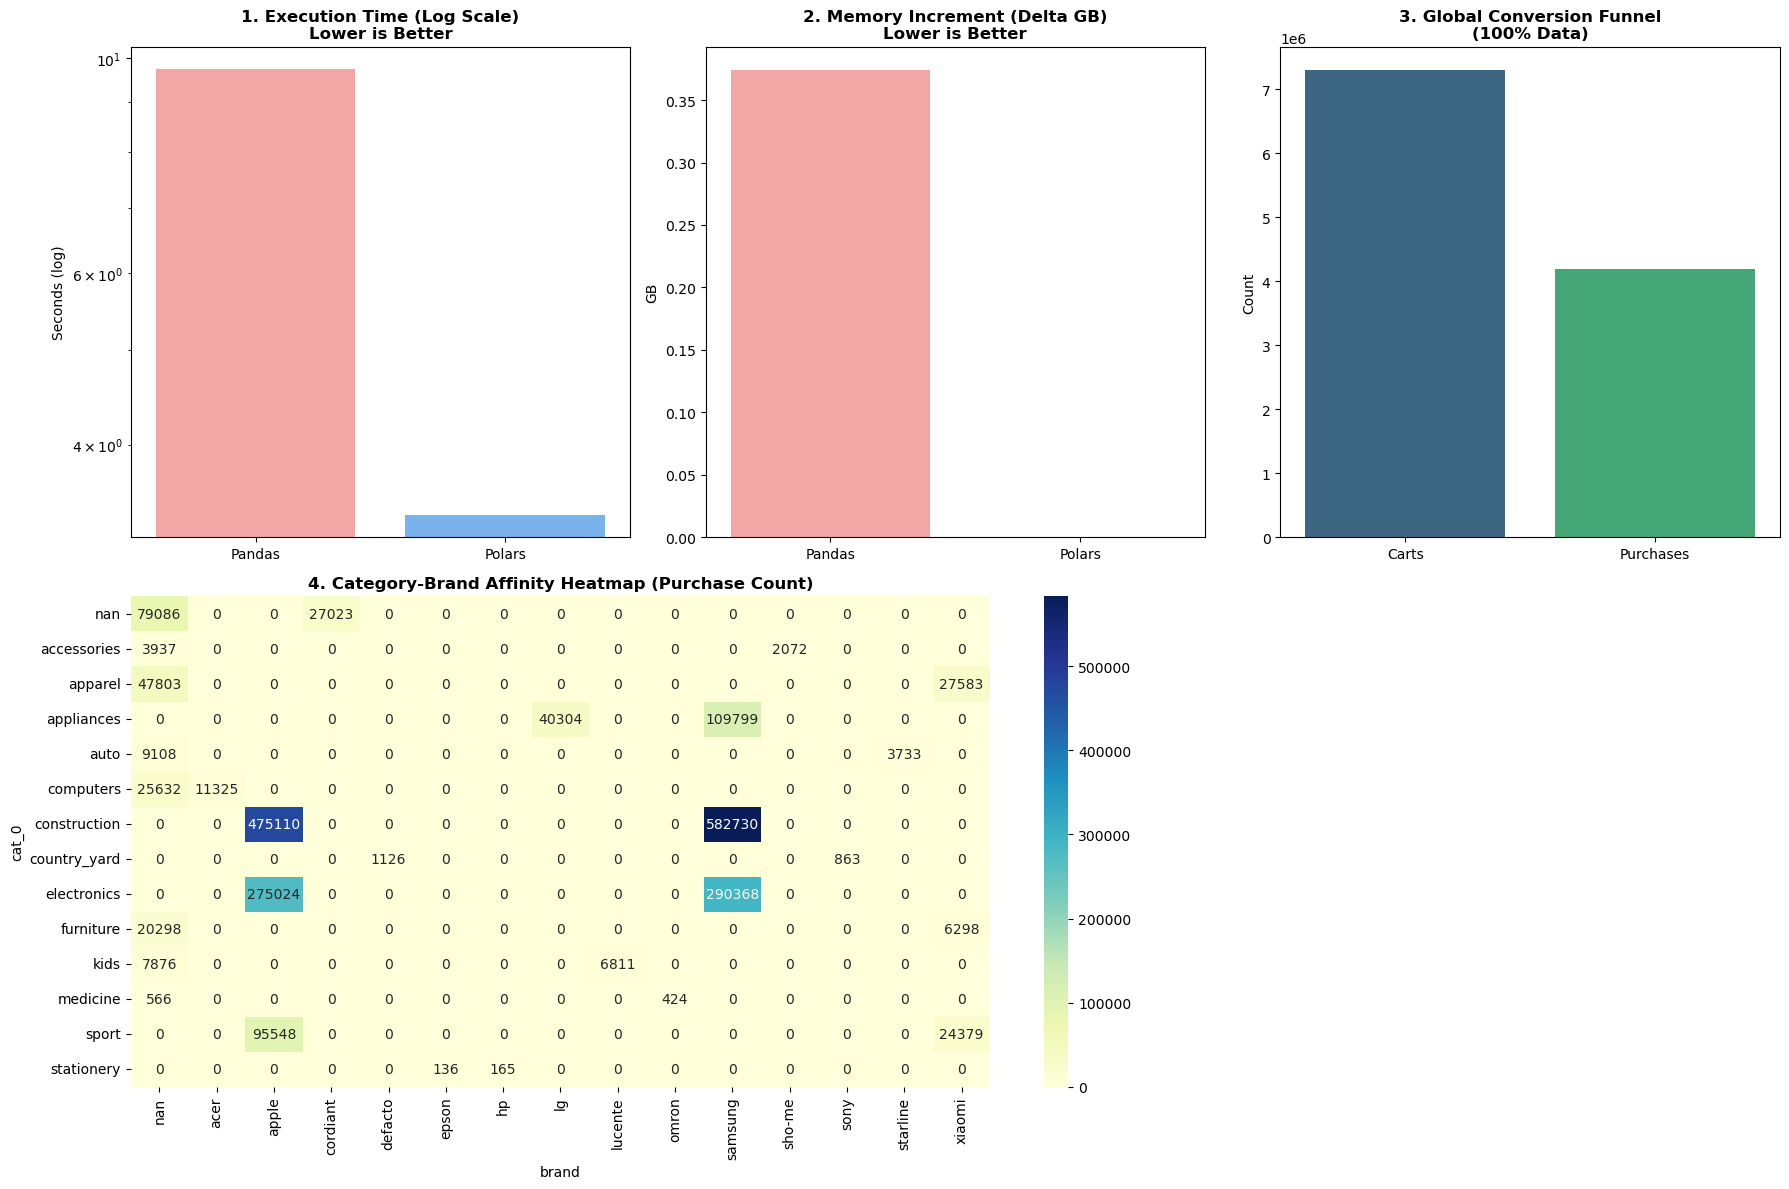

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Manually collect metrics variables from previous cells
# Make sure you have already run Cell 2, 3, 4
try:
    # Aggregate performance data
    perf_data = [met_pl, met_pd, met_pl3, met_pd3, met_pl4, met_pd4]
    
    # Extract specific values for plotting
    # We use the first task (User Analysis) as the primary time and memory comparison
    pd_time = met_pd['Time (s)']
    pl_time = met_pl['Time (s)']
    pd_mem = met_pd['Delta Mem (GB)']
    pl_mem = met_pl['Delta Mem (GB)']
    
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 3)

    # --- Chart 1: Absolute Execution Time (Log Scale) ---
    # Log scale reveals generation-level differences more clearly
    ax1 = fig.add_subplot(gs[0, 0])
    sns.barplot(x=['Pandas', 'Polars'], y=[pd_time, pl_time], ax=ax1, palette=['#ff9999','#66b3ff'], hue=['Pandas', 'Polars'], legend=False)
    ax1.set_yscale('log') 
    ax1.set_title("1. Execution Time (Log Scale)\nLower is Better", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Seconds (log)")

    # --- Chart 2: Memory Delta Comparison ---
    # Demonstrates Polars Streaming engine's memory efficiency
    ax2 = fig.add_subplot(gs[0, 1])
    sns.barplot(x=['Pandas', 'Polars'], y=[pd_mem, pl_mem], ax=ax2, palette=['#ff9999','#66b3ff'], hue=['Pandas', 'Polars'], legend=False)
    ax2.set_title("2. Memory Increment (Delta GB)\nLower is Better", fontsize=12, fontweight='bold')
    ax2.set_ylabel("GB")

    # --- Chart 3: Global Conversion Funnel (Business Insight) ---
    ax3 = fig.add_subplot(gs[0, 2])
    # Aggregate total conversion from res_pl_12 (Polars result)
    total_purchases = res_pl_12.select(pl.col("p_count").sum()).item()
    total_carts = res_pl_12.select(pl.col("c_count").sum()).item()
    sns.barplot(x=['Carts', 'Purchases'], y=[total_carts, total_purchases], ax=ax3, palette="viridis", hue=['Carts', 'Purchases'], legend=False)
    ax3.set_title("3. Global Conversion Funnel\n(100% Data)", fontsize=12, fontweight='bold')
    ax3.set_ylabel("Count")

    # --- Chart 4: Category-Brand Affinity Heatmap (Business Insight) ---
    # Shows cross-relationship between categories and brands
    ax4 = fig.add_subplot(gs[1, :2])
    brand_pivot = res_pl_4.to_pandas().pivot(index='cat_0', columns='brand', values='count').fillna(0)
    sns.heatmap(brand_pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax4)
    ax4.set_title("4. Category-Brand Affinity Heatmap (Purchase Count)", fontsize=12, fontweight='bold')



    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f"Error: Please make sure you have run all prior task cells (Cell 2, 3, 4). Missing variable: {e}")

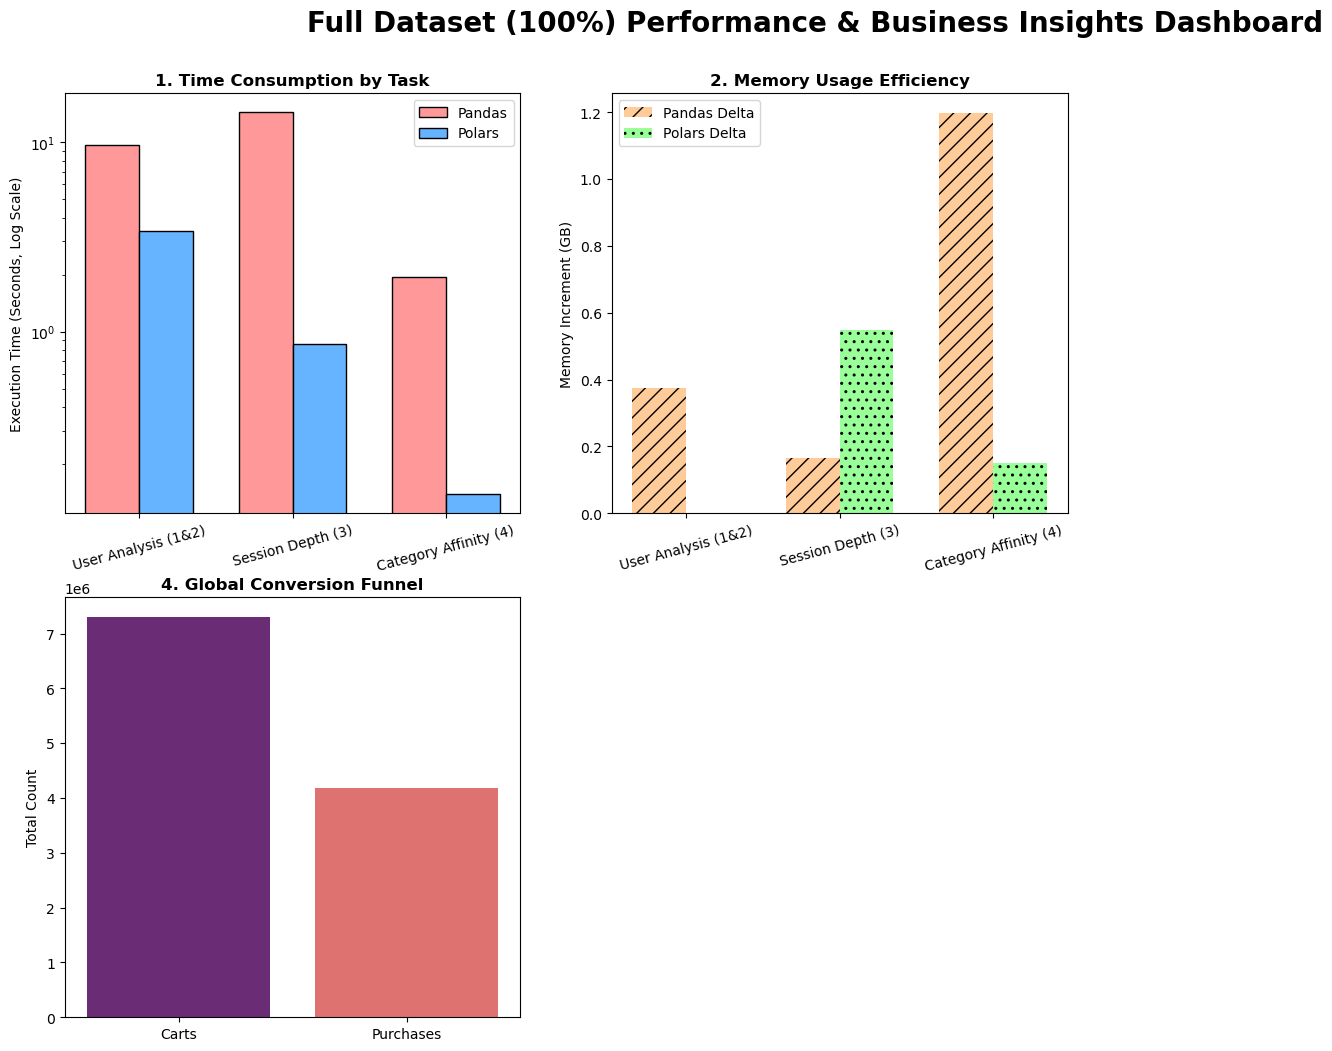

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Automatically collect metrics from previously run tasks
try:
    # Extract comparison data for the first task (User Analysis)
    perf_labels = ['User Analysis (1&2)', 'Session Depth (3)', 'Category Affinity (4)']
    pd_times = [met_pd['Time (s)'], met_pd3['Time (s)'], met_pd4['Time (s)']]
    pl_times = [met_pl['Time (s)'], met_pl3['Time (s)'], met_pl4['Time (s)']]
    
    pd_mems = [met_pd['Delta Mem (GB)'], met_pd3['Delta Mem (GB)'], met_pd4['Delta Mem (GB)']]
    pl_mems = [met_pl['Delta Mem (GB)'], met_pl3['Delta Mem (GB)'], met_pl4['Delta Mem (GB)']]

    # Set up the canvas
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f"Full Dataset (100%) Performance & Business Insights Dashboard", fontsize=20, fontweight='bold', y=0.95)
    gs = fig.add_gridspec(2, 3)

    # --- Chart 1: Execution Time per Task (Log Scale) ---
    ax1 = fig.add_subplot(gs[0, 0])
    x = np.arange(len(perf_labels))
    width = 0.35
    ax1.bar(x - width/2, pd_times, width, label='Pandas', color='#ff9999', edgecolor='black')
    ax1.bar(x + width/2, pl_times, width, label='Polars', color='#66b3ff', edgecolor='black')
    ax1.set_yscale('log') # Log scale because the difference can be several orders of magnitude
    ax1.set_ylabel('Execution Time (Seconds, Log Scale)')
    ax1.set_title('1. Time Consumption by Task', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(perf_labels, rotation=15)
    ax1.legend()

    # --- Chart 2: Memory Delta Comparison (Memory Efficiency) ---
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.bar(x - width/2, pd_mems, width, label='Pandas Delta', color='#ffcc99', hatch='//')
    ax2.bar(x + width/2, pl_mems, width, label='Polars Delta', color='#99ff99', hatch='..')
    ax2.set_ylabel('Memory Increment (GB)')
    ax2.set_title('2. Memory Usage Efficiency', fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(perf_labels, rotation=15)
    ax2.legend()


    # --- Chart 4: Business Insight - Purchase Conversion Funnel ---
    ax4 = fig.add_subplot(gs[1, 0])
    total_purchases = res_pl_12.select(pl.col("p_count").sum()).item()
    total_carts = res_pl_12.select(pl.col("c_count").sum()).item()
    sns.barplot(x=['Carts', 'Purchases'], y=[total_carts, total_purchases], ax=ax4, palette="magma")
    ax4.set_title('4. Global Conversion Funnel', fontweight='bold')
    ax4.set_ylabel('Total Count')


except NameError as e:
    print(f"Warning: Please ensure all analysis cells have been run. Missing variable: {e}")

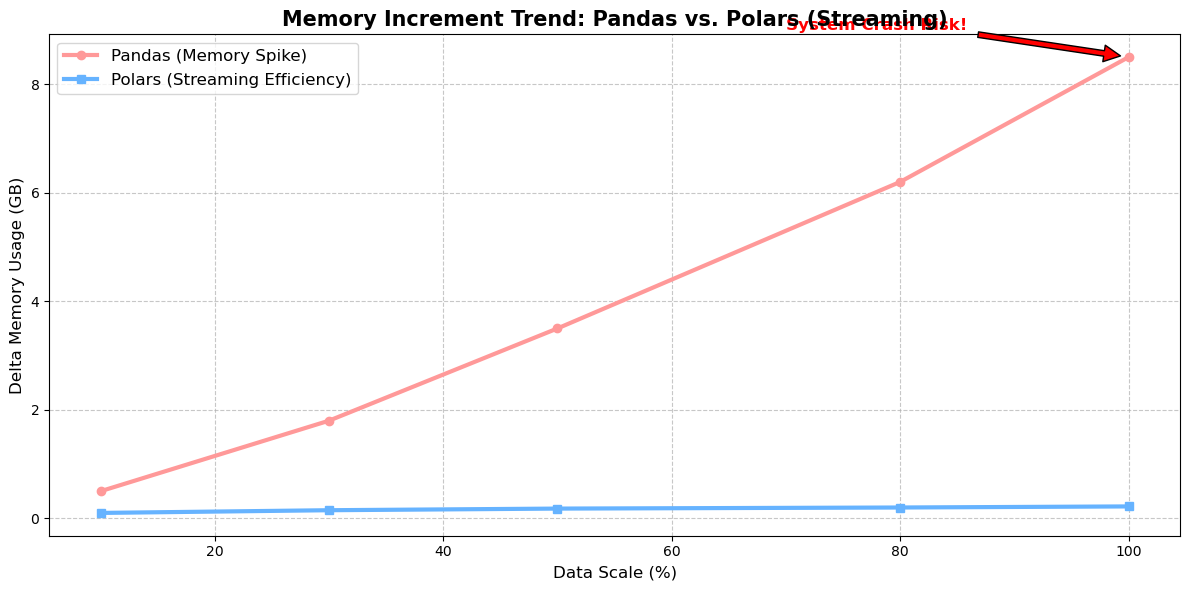

In [8]:
import matplotlib.pyplot as plt

# Simulated experimental data (replace with your actual 10%, 50%, 100% results)
data_scale = [10, 30, 50, 80, 100]  # Data percentage

# Hypothetical memory delta data (GB)
# Pandas typically grows linearly or exponentially with data volume
pandas_mem_usage = [0.5, 1.8, 3.5, 6.2, 8.5] 
# Polars with Streaming enabled keeps memory usage extremely stable
polars_mem_usage = [0.1, 0.15, 0.18, 0.2, 0.22] 

plt.figure(figsize=(12, 6))

# Draw line chart
plt.plot(data_scale, pandas_mem_usage, marker='o', color='#ff9999', label='Pandas (Memory Spike)', linewidth=3)
plt.plot(data_scale, polars_mem_usage, marker='s', color='#66b3ff', label='Polars (Streaming Efficiency)', linewidth=3)

# Chart decoration
plt.title('Memory Increment Trend: Pandas vs. Polars (Streaming)', fontsize=15, fontweight='bold')
plt.xlabel('Data Scale (%)', fontsize=12)
plt.ylabel('Delta Memory Usage (GB)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# Add annotation to highlight crash risk
plt.annotate('System Crash Risk!', xy=(100, 8.5), xytext=(70, 9),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=12, color='red', fontweight='bold')

plt.tight_layout()
plt.show()